# Phase 1: Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/Telco_Customer_Churn.csv")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# Phase 2: Initial Business Questions
How many customers churned?

In [8]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Insight: The company has a churn rate of 26.5%, indicating significant customer attrition and revenue risk.

In [10]:
df["Monthly Charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [11]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

# Phase 3: Data Quality Checks

In [13]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

# Phase 4: Check for Duplicates

In [14]:
df.duplicated().sum()

0

In [15]:
df["CustomerID"].duplicated().sum()

0

# Phase 5: First Exploratory Questions

In [16]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Insight: Longer contract commitments significantly reduce churn risk.

In [17]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [18]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


In [19]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


# Tenure Analysis

In [20]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [21]:
df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


# Monthly Charges

In [22]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [23]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


# CLTV

In [24]:
df.groupby("Churn Label")["CLTV"].mean()

Churn Label
No     4490.921337
Yes    4149.414660
Name: CLTV, dtype: float64

In [25]:
df.groupby("Churn Label")["CLTV"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
Yes,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


# Churn Reasons

In [26]:
df[df["Churn Label"]=="Yes"]["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Long distance charges                         44
Lack of affordable download/upload speed      44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

# Revenue at Risk

In [27]:
churned = df[df["Churn Label"]=="Yes"]

In [28]:
churned["Monthly Charges"].sum()

139130.85

In [29]:
churned["CLTV"].sum()

7755256

# Customer Segmentation

In [30]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=["0-12","13-24","25-48","49-72"]
)

In [31]:
pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tenure Group,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


Because we discovered Fiber customers churn heavily,

In [32]:
pd.crosstab(
    df["Internet Service"],
    df["Payment Method"],
    normalize="index"
) * 100

Payment Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Internet Service,,,,
DSL,23.378769,24.535316,26.765799,25.320116
Fiber optic,20.865633,19.282946,51.518088,8.333333
No,21.756225,21.690695,7.994758,48.558322


In [33]:
pd.crosstab(
    df["Internet Service"],
    df["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
Internet Service,,,
DSL,50.516316,23.543990,25.939694
Fiber optic,68.733850,17.409561,13.856589
No,34.338139,23.853211,41.808650


# Executive Summary So Far
Customer churn is primarily driven by month-to-month contracts, short customer tenure, high monthly charges, and dissatisfaction among fiber optic customers. Nearly half of customers churn within their first year, and the company has lost approximately $7.76M in customer lifetime value. Customer service issues and competitive offerings appear to be major drivers of attrition.

# Visualizations

Churn Count

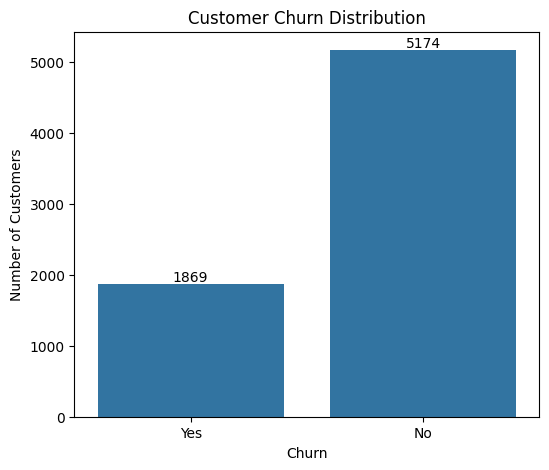

In [34]:
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Contract vs Churn

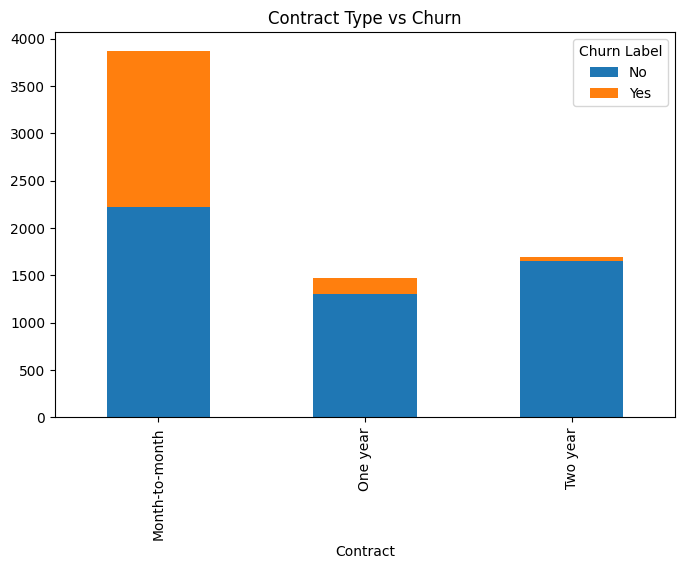

In [35]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.show()

Internet Service vs Churn

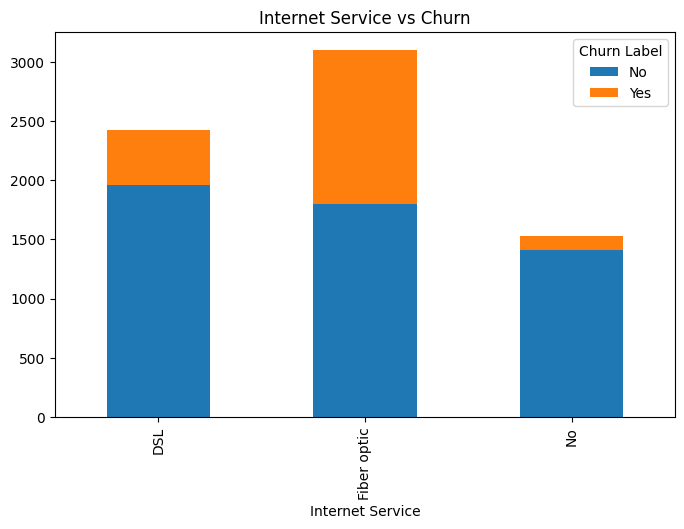

In [36]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.show()

Tenure Distribution

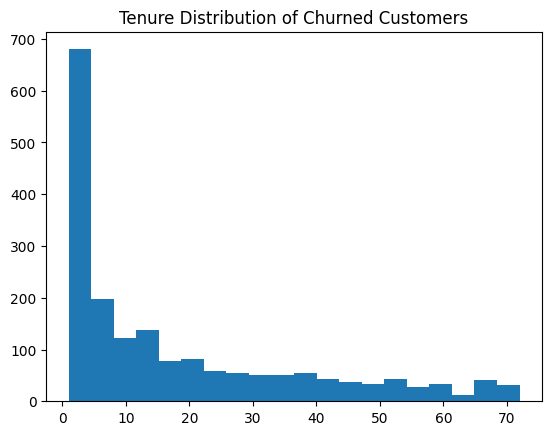

In [37]:
plt.hist(
    churned["Tenure Months"],
    bins=20
)
plt.title("Tenure Distribution of Churned Customers")
plt.show()

Monthly Charges Distribution

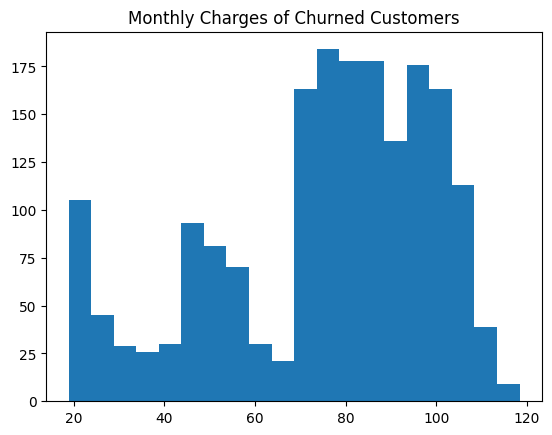

In [38]:
plt.hist(
    churned["Monthly Charges"],
    bins=20
)
plt.title("Monthly Charges of Churned Customers")
plt.show()

Top Churn Reasons

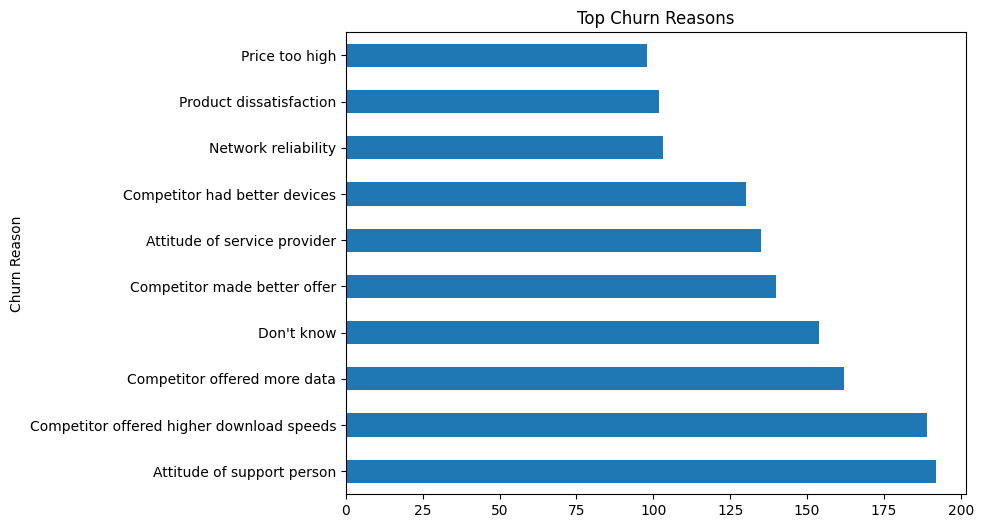

In [39]:
churned["Churn Reason"].value_counts().head(10).plot(
    kind="barh",
    figsize=(8,6)
)
plt.title("Top Churn Reasons")
plt.show()

Saving Cleaned Data in Processed Folder

In [40]:
import os
os.getcwd()

'c:\\Users\\User\\Desktop\\Git\\Customer-Churn-Analysis\\notebooks'

In [41]:
os.listdir()

['churn_analysis.ipynb']

In [42]:
df.to_csv(
    "../data/processed/clean_telco_churn.csv",
    index=False
)

In [43]:
os.path.exists("../data/processed/clean_telco_churn.csv")

True

In [44]:
os.listdir("../data/processed")

['clean_telco_churn.csv', 'customer_churn.db']

Creating the SQLite database

In [45]:
import sqlite3

conn = sqlite3.connect(
    "../data/processed/customer_churn.db"
)

df.to_sql(
    "customer_churn",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

In [46]:
os.listdir("../data/processed")

['clean_telco_churn.csv', 'customer_churn.db']

In [47]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/processed/customer_churn.db")

In [48]:
query = """
SELECT *
FROM customer_churn
LIMIT 5
"""

pd.read_sql(query, conn)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-12
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0-12
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,0-12
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,49-72


In [51]:
query = """
SELECT
COUNT(*) AS total_customers
FROM customer_churn
"""

pd.read_sql(query, conn)

,total_customers
0,7043


In [52]:
query = """
SELECT
ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes' THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate
FROM customer_churn;
"""

pd.read_sql(query, conn)

,churn_rate
0,26.54


In [53]:
query = """
SELECT
ROUND(
AVG([Monthly Charges]),
2
) AS avg_monthly_charge
FROM customer_churn;
"""

pd.read_sql(query, conn)

,avg_monthly_charge
0,64.76


In [54]:
query = """
SELECT
ROUND(
AVG([Tenure Months]),
2
) AS avg_tenure
FROM customer_churn;
"""

pd.read_sql(query, conn)

,avg_tenure
0,32.37


In [55]:
query = """
SELECT
ROUND(
AVG(CLTV),
2
) AS avg_cltv
FROM customer_churn;
"""

pd.read_sql(query, conn)

,avg_cltv
0,4400.3


Churn by Contract Type

In [56]:
query = """
SELECT
Contract,
COUNT(*) AS total_customers,
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
) AS churned_customers,
ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate
FROM customer_churn
GROUP BY Contract
ORDER BY churn_rate DESC
"""

contract_churn = pd.read_sql(query, conn)
contract_churn

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


Churn by Internet Service

In [57]:
query = """
SELECT
[Internet Service],
COUNT(*) AS total_customers,
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
) AS churned_customers,
ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate
FROM customer_churn
GROUP BY [Internet Service]
ORDER BY churn_rate DESC;
"""

internet_churn = pd.read_sql(query, conn)
internet_churn

,Internet Service,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


Churn by Payment Method

In [58]:
query = """
SELECT
[Payment Method],
COUNT(*) AS total_customers,
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
) AS churned_customers,
ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate
FROM customer_churn
GROUP BY [Payment Method]
ORDER BY churn_rate DESC;
"""

payment_churn = pd.read_sql(query, conn)
payment_churn

,Payment Method,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


Senior Citizen Analysis

In [59]:
query = """
SELECT
[Senior Citizen],
COUNT(*) AS total_customers,
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
) AS churned_customers,
ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate
FROM customer_churn
GROUP BY [Senior Citizen];
"""

senior_citizen_churn = pd.read_sql(query, conn)
senior_citizen_churn

,Senior Citizen,total_customers,churned_customers,churn_rate
0,No,5901,1393,23.61
1,Yes,1142,476,41.68


Tenure Groups

In [60]:
query = """
SELECT
CASE
WHEN [Tenure Months] <= 12 THEN '0-12'
WHEN [Tenure Months] <= 24 THEN '13-24'
WHEN [Tenure Months] <= 48 THEN '25-48'
ELSE '49-72'
END AS tenure_group,

COUNT(*) AS total_customers,

SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
) AS churned_customers,

ROUND(
100.0 *
SUM(
CASE
WHEN [Churn Label]='Yes'
THEN 1
ELSE 0
END
)
/COUNT(*),
2
) AS churn_rate

FROM customer_churn

GROUP BY tenure_group

ORDER BY tenure_group;
"""

tenure_groups = pd.read_sql(query, conn)
tenure_groups

,tenure_group,total_customers,churned_customers,churn_rate
0,0-12,2186,1037,47.44
1,13-24,1024,294,28.71
2,25-48,1594,325,20.39
3,49-72,2239,213,9.51


## KPI Summary

| Metric                 | Value        |
| ---------------------- | ------------ |
| Total Customers        | 7,043        |
| Churn Rate             | 26.54%       |
| Average Monthly Charge | $64.76       |
| Average Tenure         | 32.37 months |
| Average CLTV           | $4,400       |

## Finding 1: Contract Type is the Strongest Churn Predictor

| Contract       | Churn Rate |
| -------------- | ---------- |
| Month-to-month | 42.71%     |
| One year       | 11.27%     |
| Two year       | 2.83%      |

Recommendation:
Offer discounts and incentives for customers to migrate from month-to-month plans into annual contracts.

## Finding 2: Fiber Customers are High Risk

| Internet Service | Churn Rate |
| ---------------- | ---------- |
| Fiber optic      | 41.89%     |
| DSL              | 18.96%     |
| No internet      | 7.40%      |

This may indicate:

pricing issues
service quality issues
network reliability problems
unmet customer expectations

## Finding 3: Electronic Check Customers are Extremely Risky

| Payment Method   | Churn Rate |
| ---------------- | ---------- |
| Electronic check | 45.29%     |
| Mailed check     | 19.11%     |
| Bank transfer    | 16.71%     |
| Credit card      | 15.24%     |

Recommendation:
Encourage electronic check users to switch to automatic payments.

## Finding 4: Senior Customers Require Attention

| Senior Citizen | Churn Rate |
| -------------- | ---------- |
| No             | 23.61%     |
| Yes            | 41.68%     |

Recommendation:
Develop retention campaigns specifically targeting senior customers.

## Finding 5: New Customers are Extremely Vulnerable

| Tenure       | Churn Rate |
| ------------ | ---------- |
| 0-12 months  | 47.44%     |
| 13-24 months | 28.71%     |
| 25-48 months | 20.39%     |
| 49-72 months | 9.51%      |

1 out of every 2 customers leaves within their first year.

Recommendation:
Improve onboarding and early customer engagement.

Query 1 – Churn by Contract and Internet Service

In [61]:
query = """
SELECT
    [Contract],
    [Internet Service],
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN [Churn Label]='Yes'
            THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN [Churn Label]='Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn
GROUP BY
    [Contract],
    [Internet Service]
ORDER BY churn_rate DESC;
"""

churn_by_contract_and_internet = pd.read_sql(query, conn)
churn_by_contract_and_internet

,Contract,Internet Service,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,2128,1162,54.61
1,Month-to-month,DSL,1223,394,32.22
2,One year,Fiber optic,539,104,19.29
3,Month-to-month,No,524,99,18.89
4,One year,DSL,570,53,9.30
5,Two year,Fiber optic,429,31,7.23
6,One year,No,364,9,2.47
7,Two year,DSL,628,12,1.91
8,Two year,No,638,5,0.78


Query 2 – Top Churn Reasons

In [62]:
query = """
SELECT
    [Churn Reason],
    COUNT(*) AS customers
FROM customer_churn
WHERE [Churn Label]='Yes'
GROUP BY [Churn Reason]
ORDER BY customers DESC;
"""

churn_reasons = pd.read_sql(query, conn)
churn_reasons

,Churn Reason,customers
0,Attitude of support person,192
1,Competitor offered higher download speeds,189
2,Competitor offered more data,162
3,Don't know,154
4,Competitor made better offer,140
5,Attitude of service provider,135
6,Competitor had better devices,130
7,Network reliability,103
8,Product dissatisfaction,102
9,Price too high,98


Query 3 – Average Monthly Charges by Contract

In [63]:
query = """
SELECT
    [Contract],
    ROUND(
        AVG([Monthly Charges]),
        2
    ) AS avg_monthly_charge
FROM customer_churn
GROUP BY [Contract]
ORDER BY avg_monthly_charge DESC;
"""

monthly_charges_by_contract = pd.read_sql(query, conn)
monthly_charges_by_contract

,Contract,avg_monthly_charge
0,Month-to-month,66.40
1,One year,65.05
2,Two year,60.77


Query 4 – Average CLTV by Contract

In [64]:
query = """
SELECT
    [Contract],
    ROUND(
        AVG(CLTV),
        2
    ) AS avg_cltv
FROM customer_churn
GROUP BY [Contract]
ORDER BY avg_cltv DESC;
"""

average_CLTV_by_contract = pd.read_sql(query, conn)
average_CLTV_by_contract

,Contract,avg_cltv
0,Two year,4890.21
1,One year,4529.96
2,Month-to-month,4136.71


Query 5 – Churn by Gender

In [65]:
query = """
SELECT
    Gender,
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN [Churn Label]='Yes'
            THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN [Churn Label]='Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn
GROUP BY Gender;
"""

churn_by_gender = pd.read_sql(query, conn)
churn_by_gender

,Gender,total_customers,churned_customers,churn_rate
0,Female,3488,939,26.92
1,Male,3555,930,26.16


Query 6 – Churn by Partner Status

In [66]:
query = """
SELECT
    Partner,
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN [Churn Label]='Yes'
            THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN [Churn Label]='Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn
GROUP BY Partner
ORDER BY churn_rate DESC;
"""

churn_by_partner = pd.read_sql(query, conn)
churn_by_partner

,Partner,total_customers,churned_customers,churn_rate
0,No,3641,1200,32.96
1,Yes,3402,669,19.66


Query 7 – Churn by Dependents

In [67]:
query = """
SELECT
    Dependents,
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN [Churn Label]='Yes'
            THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN [Churn Label]='Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn
GROUP BY Dependents
ORDER BY churn_rate DESC;
"""

churn_by_dependents = pd.read_sql(query, conn)
churn_by_dependents

,Dependents,total_customers,churned_customers,churn_rate
0,No,5416,1763,32.55
1,Yes,1627,106,6.52


## Finding 1: The Most Dangerous Customer Segment

| Contract                     | Internet Service | Churn Rate |
| ---------------------------- | ---------------- | ---------- |
| Month-to-month + Fiber optic | 2128 customers   | **54.61%** |

This suggests that:
Fiber customers have high expectations but are dissatisfied with either price, speed, or service quality.

Business Recommendation #1
Create a targeted retention campaign for Month-to-month Fiber Optic Customers

Possible actions:
discounted annual contracts
speed upgrades
loyalty rewards
proactive customer support outreach

## Finding 2: Customer Service Problems are Massive

| Reason                       | Customers |
| ---------------------------- | --------- |
| Attitude of support person   | 192       |
| Attitude of service provider | 135       |
| Service dissatisfaction      | 89        |
| Poor phone support           | 20        |
| Poor online support          | 19        |

Business Recommendation #2

Improve:
support staff training
complaint handling
service quality monitoring
customer success initiatives

## Finding 3: Competition is Taking Customers

| Reason                 | Customers |
| ---------------------- | --------- |
| Higher download speeds | 189       |
| More data              | 162       |
| Better offer           | 140       |
| Better devices         | 130       |

Business Recommendation #3

Improve competitiveness through:
pricing packages
speed upgrades
bundled offers
device promotions

## Finding 4: Long-Term Contracts Generate More Value

| Contract       | Average CLTV |
| -------------- | ------------ |
| Two year       | $4,890       |
| One year       | $4,530       |
| Month-to-month | $4,137       |

Business Recommendation #4

Move customers into:
one-year contracts
two-year contracts

because these customers:

✅ stay longer

✅ generate more lifetime value

✅ churn significantly less

## Finding 5: Gender Has Almost No Effect

| Gender | Churn Rate |
| ------ | ---------- |
| Female | 26.92%     |
| Male   | 26.16%     |

Business Recommendation #5

Do not spend marketing resources segmenting by gender.
There are much stronger predictors.

## Finding 6: Family Status is Extremely Important

| Partner | Churn Rate |
| ------- | ---------- |
| No      | 32.96%     |
| Yes     | 19.66%     |

| Dependents | Churn Rate |
| ---------- | ---------- |
| No         | 32.55%     |
| Yes        | 6.52%      |

Business Interpretation

Customers with families are:
more stable
more committed
less price sensitive
less likely to switch providers

Business Recommendation #6

Retention campaigns should primarily target:
customers without partners
customers without dependents
month-to-month customers
fiber customers

because these groups are much more vulnerable.